In [6]:
import os
from dataclasses import dataclass
from math import gcd
from typing import Optional

import matplotlib.pyplot as plt # Python package for ploting
import neurokit2 as nk # python package for physiological signal processing
import numpy as np
import scipy.signal # python package for signal processing 
from scipy.signal import butter, filtfilt

In [7]:
@dataclass
class PPGPreprocessor:
    fs_target: float = 125        
    lowcut: float = 0.5             
    highcut: float = 8.0            
    filter_order: int = 4           
    remove_dc: bool = True          
    detrend: bool = True            
    detrend_order: int = 2          
    clip_std: Optional[float] = 5.0 
    median_kernel: Optional[int] = None  
    normalize: bool = True          

    def process_continuous(self, ppg: np.ndarray, fs: float) -> np.ndarray:
        """Applies global filtering to the entire continuous recording BEFORE segmentation."""
        signal = np.asarray(ppg, dtype=np.float64).ravel()
        signal = self._resample(signal, fs)
        signal = self._clip_outliers(signal)
        signal = self._median_filter(signal)
        signal = self._bandpass_filter(signal)
        signal = self._remove_dc(signal)
        signal = self._detrend(signal)
        return signal
    
    def normalize_segment(self, segment: np.ndarray) -> np.ndarray:
        """Applies [0, 1] Min-Max normalisation to a single 1D window."""
        if not self.normalize:
            return segment
            
        min_val = segment.min()
        max_val = segment.max()
        rng = max_val - min_val
        
        if rng == 0:
            rng = 1.0
            
        return (segment - min_val) / rng

    def _resample(self, signal: np.ndarray, fs: float) -> np.ndarray:
        if fs == self.fs_target:
            return signal
        fs_int = int(round(fs))
        fs_target_int = int(round(self.fs_target))
        g = gcd(fs_target_int, fs_int)
        return scipy.signal.resample_poly(signal, fs_target_int // g, fs_int // g)

    def _clip_outliers(self, signal: np.ndarray) -> np.ndarray:
        if self.clip_std is None:
            return signal
        mu, sigma = signal.mean(), signal.std()
        if sigma == 0:
            return signal
        return np.clip(signal, mu - self.clip_std * sigma, mu + self.clip_std * sigma)

    def _median_filter(self, signal: np.ndarray) -> np.ndarray:
        if self.median_kernel is None:
            return signal
        kernel = self.median_kernel if self.median_kernel % 2 == 1 else self.median_kernel + 1
        return scipy.signal.medfilt(signal, kernel_size=kernel)

    def _bandpass_filter(self, signal: np.ndarray) -> np.ndarray:
        nyq = self.fs_target / 2.0
        b, a = butter(self.filter_order, [self.lowcut / nyq, self.highcut / nyq], btype="band")
        return filtfilt(b, a, signal)

    def _remove_dc(self, signal: np.ndarray) -> np.ndarray:
        if not self.remove_dc:
            return signal
        return signal - np.mean(signal)

    def _detrend(self, signal: np.ndarray) -> np.ndarray:
        if not self.detrend:
            return signal
        t = np.arange(len(signal), dtype=np.float64)
        coeffs = np.polyfit(t, signal, self.detrend_order)
        trend = np.polyval(coeffs, t)
        return signal - trend

Frequency Range of ECG Signal : 0.1 Hz to 30 Hz 

In [8]:
#  ECG Preprocessing & HR Extraction
def process_ecg_signal(ecg_signal: np.ndarray, sr: int = 64) -> np.ndarray:
 
    nyq = 0.5 * sr
    low  = 0.1 / nyq
    # Keep 0.5 Hz margin from Nyquist to avoid filter instability at any SR
    high = min(30.0, sr / 2.0 - 0.5) / nyq

    b, a = butter(4, [low, high], btype='band')
    ecg_filtered = filtfilt(b, a, ecg_signal)

    # Mean removal AFTER bandpass (0th-order detrend)
    ecg_filtered = ecg_filtered - np.mean(ecg_filtered)
    return ecg_filtered

In [9]:
def extract_hr_from_ecg(ecg_segment: np.ndarray, sr: int = 64) -> float:

    try:
        ecg_filtered = process_ecg_signal(ecg_segment, sr)

        mu, sigma = np.mean(ecg_filtered), np.std(ecg_filtered)
        if sigma == 0:
            return np.nan
        ecg_clipped = np.clip(ecg_filtered, mu - 4 * sigma, mu + 4 * sigma) # Outlier clipping to improve peak detection robustness

        _, info = nk.ecg_peaks(ecg_clipped, sampling_rate=sr, method="neurokit") # Here I used neurokit to detect R-peaks in the ECG signal. The method "neurokit" is a specific algorithm for peak detection that is part of the NeuroKit2 library. It is designed to be robust and accurate for ECG signals, making it a good choice for this application. The function returns a dictionary containing the indices of the detected R-peaks, which are then used to calculate the heart rate.
        rpeaks = info["ECG_R_Peaks"]

        if len(rpeaks) < 2:
            return np.nan

        # RR-interval validation (physiological bounds) 
        rr_intervals = np.diff(rpeaks) / sr # seconds
        valid_rr = rr_intervals[(rr_intervals > 0.3) & (rr_intervals < 1.5)] # Keep only RR intervals between 0.3s (200 bpm) and 1.5s (40 bpm) : 1 / peak to peak time in seconds

        if len(valid_rr) < 1:
            return np.nan

        return float(60.0 / np.mean(valid_rr))# bpm

    except Exception:
        return np.nan

https://neuropsychology.github.io/NeuroKit/

In [10]:
# Dataset Loading & Segmentation
def load_itw_data(
    data_dir: str,
    subjects: Optional[list] = None,
    activities: Optional[list] = None,
    segment_duration: int = 10,
    overlap: int = 2,
    target_sr: int = 125,
    original_sr: int = 64,
    location: str = 'L'
) -> dict:
    """
    Load, clean, and segment the ITW wrist-PPG + chest-ECG dataset.
    """
    all_activities = ['stationary']

    if activities is None:
        activities = all_activities

    if subjects is None:
        subjects = [f'S{str(i).zfill(2)}' for i in range(1, 31)]

    print("=" * 60)
    print("Loading ITW Dataset")
    print("=" * 60)
    print(f"  Subjects        : {len(subjects)}")
    print(f"  Activities      : {activities}")
    print(f"  Wrist location  : {location}")
    print(f"  Window duration : {segment_duration} s")
    print(f"  Overlap         : {overlap} s  (step = {segment_duration - overlap} s)")
    print(f"  Input SR        : {original_sr} Hz")
    print(f"  Output SR       : {target_sr} Hz")
    print(f"  HR source       : ECG R-peaks (NeuroKit2)")
    print("-" * 60)

    signals, imu_signals, hr_labels, subject_ids, trial_ids, activity_labels = [], [], [], [], [], []


    # SETUP DUAL INDICES (Because ECG is 64Hz, but PPG becomes 125Hz)
    samples_per_segment_orig = int(segment_duration * original_sr)
    step_samples_orig        = int((segment_duration - overlap) * original_sr)
    
    samples_per_segment_tgt  = int(segment_duration * target_sr)
    step_samples_tgt         = int((segment_duration - overlap) * target_sr)

    # Initialize your new PPG Processor
    ppg_processor = PPGPreprocessor(fs_target=float(target_sr), normalize=True)

    skipped_no_file = 0
    skipped_bad_hr  = 0

    for subj in subjects:
        for act in activities:
            ppg_file = os.path.join(data_dir, f"{subj}{location}_{act}_ppg.npy")
            imu_file = os.path.join(data_dir, f"{subj}{location}_{act}_imu.npy")
            ecg_file = os.path.join(data_dir, f"{subj}_{act}_ecg.npy")

            if not os.path.exists(ppg_file) or not os.path.exists(ecg_file) or not os.path.exists(imu_file):
                skipped_no_file += 1
                print(f"  Skipping {subj} {act} (missing file)")
                print(f"    Expected files: {ppg_file}, {ecg_file}, {imu_file}")
                continue

            ppg = np.load(ppg_file).flatten()
            ecg = np.load(ecg_file).flatten()
            imu = np.load(imu_file)

            # ensure shape is (N,3)
            if imu.ndim == 2 and imu.shape[1] == 3:
                imu = np.sqrt(imu[:,0]**2 + imu[:,1]**2 + imu[:,2]**2)
            else:
                raise ValueError(f"Unexpected IMU shape: {imu.shape}")

            # Align lengths in case of minor recording discrepancies
            min_len = min(len(ppg), len(ecg), len(imu))
            ppg = ppg[:min_len]
            ecg = ecg[:min_len]
            imu = imu[:min_len]

            # We filter and resample the ENTIRE continuous recording right here.
            ppg_global = ppg_processor.process_continuous(ppg, fs=float(original_sr))
            imu_global = ppg_processor.process_continuous(imu, fs=float(original_sr))

            seg_idx = 0
            start_orig = 0
            start_tgt  = 0

            # SEGMENTATION & LOCAL NORMALISATION 
            while start_orig + samples_per_segment_orig <= min_len:
                end_orig = start_orig + samples_per_segment_orig
                end_tgt  = start_tgt + samples_per_segment_tgt

                # Safety check: polyphase resampling lengths can occasionally round off by 1
                if end_tgt > len(ppg_global) or end_tgt > len(imu_global):
                    break

                # Slice ECG (using 64Hz indices) and get HR
                ecg_segment = ecg[start_orig:end_orig]
                hr = extract_hr_from_ecg(ecg_segment, sr=original_sr)

                if np.isnan(hr) or hr < 40.0 or hr > 200.0:
                    skipped_bad_hr += 1
                    start_orig += step_samples_orig
                    start_tgt  += step_samples_tgt
                    continue

                # Slice the already-cleaned PPG (using 125Hz indices)
                ppg_segment = ppg_global[start_tgt:end_tgt]
                imu_segment = imu_global[start_tgt:end_tgt]
                
        
                ppg_segment_normalized = ppg_processor.normalize_segment(ppg_segment)
                imu_segment_normalized = ppg_processor.normalize_segment(imu_segment)

                # Store the final segment
                signals.append(ppg_segment_normalized)
                imu_signals.append(imu_segment_normalized)  
                hr_labels.append(hr)
                subject_ids.append(subj)
                trial_ids.append(f"{subj}_{act}_{seg_idx:04d}")
                activity_labels.append(act)

                # Move windows forward
                seg_idx += 1
                start_orig += step_samples_orig
                start_tgt  += step_samples_tgt

    data = {
        "signal"      : np.array(signals,          dtype=np.float32),
        "imu_signal"  : np.array(imu_signals,      dtype=np.float32),
        "HR"          : np.array(hr_labels,        dtype=np.float32),
        "subject_ids" : np.array(subject_ids),
        "trial_ids"   : np.array(trial_ids),
        "activities"  : np.array(activity_labels),
    }

    print(f"\n  Total valid segments  : {len(signals)}")
    print(f"  Skipped (missing file): {skipped_no_file}")
    print(f"  Skipped (bad HR)      : {skipped_bad_hr}")
    if len(signals) > 0:
        print(f"  Signal array shape    : {data['signal'].shape}")
        print(f"  IMU signal array shape: {data['imu_signal'].shape}")
        print(f"  HR range              : {data['HR'].min():.1f} – {data['HR'].max():.1f} bpm")
        print(f"  HR mean ± std         : {data['HR'].mean():.1f} ± {data['HR'].std():.1f} bpm")
    print("=" * 60)

    return data

In [11]:
# Visualisation — ECG + R-peaks across all activities 
def plot_ecg_r_peaks_for_paper(
    data_dir: str,
    subject: str = "S01",
    duration: int = 10,
    sr: int = 64,
    skip_seconds: int = 0,
    save_path: Optional[str] = None
) -> None:

    activities   = ['stationary']
    plot_titles  = ['(a) Stationary']

    samples      = int(duration * sr)
    time_axis    = np.linspace(0, duration, samples)
    start_offset = int(skip_seconds * sr)

    n_activities = len(activities)
    ncols = min(3, n_activities)
    nrows = int(np.ceil(n_activities / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 6))
    fig.suptitle(
        f"ECG Signal with Detected R-peaks — Subject {subject}",
        fontsize=14, fontweight='bold', y=1.01
    )

    # Normalize axes handling for 1D and scalar return values
    if n_activities == 1:
        axes = np.array([axes])
    else:
        axes = np.array(axes).reshape(-1)

    for i, (act, title) in enumerate(zip(activities, plot_titles)):
        ax = axes[i]

        ecg_file = os.path.join(data_dir, f"{subject}_{act}_ecg.npy")

        if not os.path.exists(ecg_file):
            ax.text(0.5, 0.5, f'File missing:\n{os.path.basename(ecg_file)}',
                    ha='center', va='center', transform=ax.transAxes,
                    fontsize=9, color='red')
            ax.set_title(title, fontsize=11)
            continue

        ecg_raw = np.load(ecg_file).flatten()

        start_idx = start_offset if len(ecg_raw) >= start_offset + samples else 0
        ecg_segment = ecg_raw[start_idx: start_idx + samples]

        #  Preprocess 
        ecg_filtered = process_ecg_signal(ecg_segment, sr)

        # Amplitude spike clipping before peak detection (same as HR extraction)
        mu, sigma = np.mean(ecg_filtered), np.std(ecg_filtered)
        ecg_clipped = np.clip(ecg_filtered, mu - 4 * sigma, mu + 4 * sigma)

        #  Amplitude normalise to [−1, 1] for display only 
        sig_min, sig_max = ecg_clipped.min(), ecg_clipped.max()
        sig_range = sig_max - sig_min if sig_max != sig_min else 1.0
        ecg_display = 2.0 * (ecg_clipped - sig_min) / sig_range - 1.0

        # R-peak detection
        try:
            _, info  = nk.ecg_peaks(ecg_clipped, sampling_rate=sr, method="neurokit")
            rpeaks   = info["ECG_R_Peaks"]

            # HR from this display window
            if len(rpeaks) >= 2:
                rr = np.diff(rpeaks) / sr
                valid_rr = rr[(rr > 0.3) & (rr < 1.5)]
                hr_display = 60.0 / np.mean(valid_rr) if len(valid_rr) >= 1 else float('nan')
            else:
                hr_display = float('nan')

        except Exception:
            rpeaks     = np.array([], dtype=int)
            hr_display = float('nan')

        # Plot 
        ax.plot(time_axis, ecg_display, color='#1f77b4', linewidth=1.0,
                label='ECG (filtered)')

        if len(rpeaks) > 0:
            valid_peaks = rpeaks[rpeaks < len(ecg_display)]
            ax.plot(time_axis[valid_peaks], ecg_display[valid_peaks],
                    'ro', markersize=4, zorder=5, label='R-peak')

        # Formatting 
        hr_str = f"{hr_display:.1f} bpm" if not np.isnan(hr_display) else "HR: N/A"
        ax.set_title(f"{title}  |  HR = {hr_str}", fontsize=10)
        ax.set_xlim([0, duration])
        ax.set_ylim([-1.6, 1.6])

        # Only add axis labels at edges to save space
        if i // 3 == 1:                        # bottom row
            ax.set_xlabel('Time (s)', fontsize=10)
        if i % 3 == 0:                         # left column
            ax.set_ylabel('Normalised ECG (a.u.)', fontsize=10)

        ax.tick_params(labelsize=9)
        ax.grid(True, linestyle='--', alpha=0.4)

        # Legend only on first panel
        if i == 0:
            ax.legend(fontsize=8, loc='upper right')

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    else:
        plt.show()

Loading ITW Dataset
  Subjects        : 30
  Activities      : ['stationary']
  Wrist location  : L
  Window duration : 10 s
  Overlap         : 2 s  (step = 8 s)
  Input SR        : 64 Hz
  Output SR       : 125 Hz
  HR source       : ECG R-peaks (NeuroKit2)
------------------------------------------------------------

  Total valid segments  : 1770
  Skipped (missing file): 0
  Skipped (bad HR)      : 0
  Signal array shape    : (1770, 1250)
  IMU signal array shape: (1770, 1250)
  HR range              : 53.5 – 113.3 bpm
  HR mean ± std         : 79.6 ± 11.1 bpm


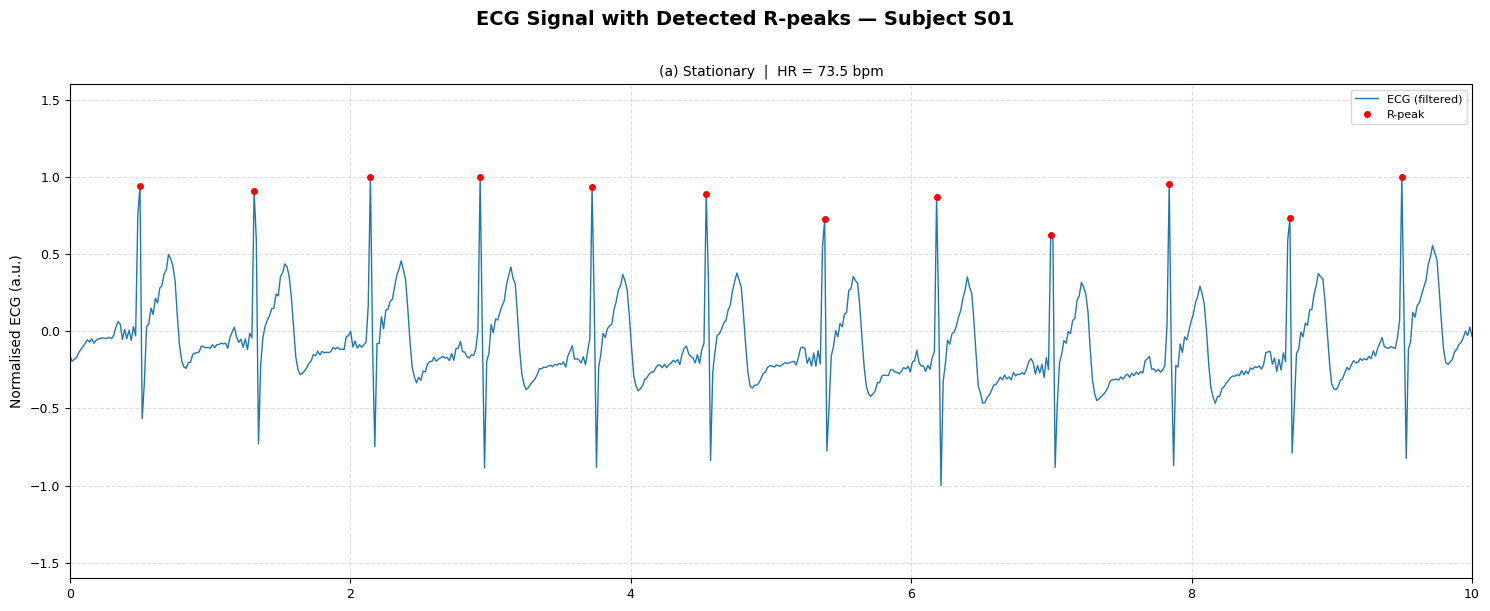

In [12]:
# Entry point
if __name__ == "__main__":
    DATA_DIR = "./Data"

    # Build cleaned dataset
    dataset_Left = load_itw_data(
        data_dir         = DATA_DIR,
        subjects         = None,        # None - all 30 subjects
        activities       = None,        # None - all 6 activities
        segment_duration = 10,
        overlap          = 2,
        target_sr        = 125,
        original_sr      = 64,
        location         = 'L'
    )

    plot_ecg_r_peaks_for_paper(
        data_dir   = DATA_DIR,
        subject    = "S01",
        duration   = 10,
        sr         = 64,
        save_path  = None  # set None to display interactively
    )

In [22]:
import sys
print(sys.executable)

c:\Program Files\Python311\python.exe


In [23]:
%matplotlib widget

In [24]:
def plot_ecg_peaks_scrollable(
    data_dir: str,
    subject: str = "S01",
    sr: int = 64,
    window_duration: int = 10,
    save_path: Optional[str] = None
) -> None:
 
    ecg_file = os.path.join(data_dir, f"{subject}_stationary_ecg.npy")
    
    if not os.path.exists(ecg_file):
        print(f"File not found: {ecg_file}")
        return
    
    ecg_raw = np.load(ecg_file).flatten()
    window_samples = int(window_duration * sr)
    num_windows = (len(ecg_raw) - window_samples) // window_samples + 1
    
    current_window = [0]  # Use list to allow modification in nested function
    
    fig, ax = plt.subplots(figsize=(10, 7))
    plt.subplots_adjust(bottom=0.2)
    
    def update_plot(window_idx):
        ax.clear()
        window_idx = int(np.clip(window_idx, 0, num_windows - 1))
        current_window[0] = window_idx
        
        start_idx = window_idx * window_samples
        end_idx = start_idx + window_samples
        ecg_segment = ecg_raw[start_idx:end_idx]
        
        # Preprocess
        ecg_filtered = process_ecg_signal(ecg_segment, sr)
        mu, sigma = np.mean(ecg_filtered), np.std(ecg_filtered)
        ecg_clipped = np.clip(ecg_filtered, mu - 4 * sigma, mu + 4 * sigma)
        
        # Normalize for display
        sig_min, sig_max = ecg_clipped.min(), ecg_clipped.max()
        sig_range = sig_max - sig_min if sig_max != sig_min else 1.0
        ecg_display = 2.0 * (ecg_clipped - sig_min) / sig_range - 1.0
        
        time_axis = np.linspace(0, window_duration, len(ecg_segment))
        
        # Detect R-peaks
        try:
            _, info = nk.ecg_peaks(ecg_clipped, sampling_rate=sr, method="neurokit")
            rpeaks = info["ECG_R_Peaks"]
            
            if len(rpeaks) >= 2:
                rr = np.diff(rpeaks) / sr
                valid_rr = rr[(rr > 0.3) & (rr < 1.5)]
                hr_display = 60.0 / np.mean(valid_rr) if len(valid_rr) >= 1 else float('nan')
            else:
                hr_display = float('nan')
        except Exception:
            rpeaks = np.array([], dtype=int)
            hr_display = float('nan')
        
        # Plot
        ax.plot(time_axis, ecg_display, color='#1f77b4', linewidth=1.2, label='ECG (filtered)')
        
        if len(rpeaks) > 0:
            valid_peaks = rpeaks[rpeaks < len(ecg_display)]
            ax.plot(time_axis[valid_peaks], ecg_display[valid_peaks],
                    'ro', markersize=6, zorder=5, label='R-peak')
        
        hr_str = f"{hr_display:.1f} bpm" if not np.isnan(hr_display) else "HR: N/A"
        ax.set_title(f"ECG with R-peaks — {subject} Stationary | Window {window_idx+1}/{num_windows} | HR = {hr_str}", 
                     fontsize=12, fontweight='bold')
        ax.set_xlabel('Time (s)', fontsize=11)
        ax.set_ylabel('Normalised ECG (a.u.)', fontsize=11)
        ax.set_xlim([0, window_duration])
        ax.set_ylim([-1.6, 1.6])
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize=10, loc='upper right')
    
    # Initial plot
    update_plot(0)
    
    # Slider for navigation
    ax_slider = plt.axes([0.2, 0.05, 0.6, 0.03])
    slider = plt.Slider(ax_slider, 'Window', 0, num_windows - 1, valinit=0, valstep=1)
    slider.on_changed(lambda val: update_plot(val))
    
    # Keyboard navigation
    def on_key(event):
        if event.key == 'right':
            slider.set_val(min(current_window[0] + 1, num_windows - 1))
        elif event.key == 'left':
            slider.set_val(max(current_window[0] - 1, 0))
    
    fig.canvas.mpl_connect('key_press_event', on_key)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    else:
        plt.show()


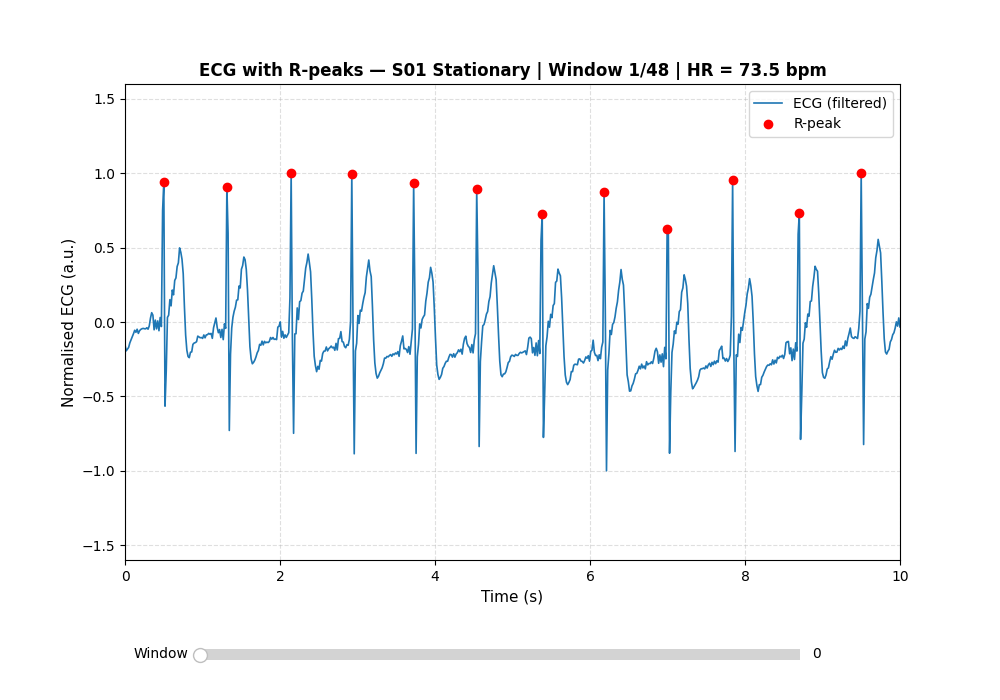

In [25]:
plot_ecg_peaks_scrollable(
    data_dir=DATA_DIR,
    subject="S01",
    sr=64,
    window_duration=10
)

In [26]:
import pandas as pd

# Convert to DataFrame for easier inspection
df_left_sat = pd.DataFrame({
    'HR': dataset_Left['HR'],
    'subject_ids': dataset_Left['subject_ids'],
    'trial_ids': dataset_Left['trial_ids'],
    'activities': dataset_Left['activities'],
    'signal': list(dataset_Left['signal'],) , # Store signals as lists in the DataFrame
    'imu_signal': list(dataset_Left['imu_signal'],)  # Store IMU signals as lists in the DataFrame
})

df_left_sat.head()

,HR,subject_ids,trial_ids,activities,signal,imu_signal
0,73.460869,S01,S01_stationary_0000,stationary,"[0.54071355, 0.5199219, 0.5002164, 0.48260945,...","[0.3071396, 0.42779496, 0.54497945, 0.65542305..."
1,71.593224,S01,S01_stationary_0001,stationary,"[0.55872375, 0.5268357, 0.49490494, 0.46341315...","[0.41093397, 0.4070761, 0.39329052, 0.37411198..."
2,73.142860,S01,S01_stationary_0002,stationary,"[0.79013175, 0.7998803, 0.80881065, 0.81691146...","[0.33728987, 0.31793776, 0.30489674, 0.3007818..."
3,74.235504,S01,S01_stationary_0003,stationary,"[0.20968792, 0.24069478, 0.27246895, 0.3043628...","[0.6260664, 0.6391024, 0.63527673, 0.61580473,..."
4,72.702240,S01,S01_stationary_0004,stationary,"[0.29372278, 0.25231445, 0.21387137, 0.1789329...","[0.3662588, 0.38253495, 0.40762582, 0.43810356..."


In [18]:
df_left_sat.describe()

,HR
count,1770.000000
mean,79.648979
std,11.065704
min,53.545818
25%,71.408693
50%,79.448273
75%,87.107750
max,113.333336


In [19]:
df_left_sat.isna().sum()

HR             0
subject_ids    0
trial_ids      0
activities     0
signal         0
imu_signal     0
dtype: int64

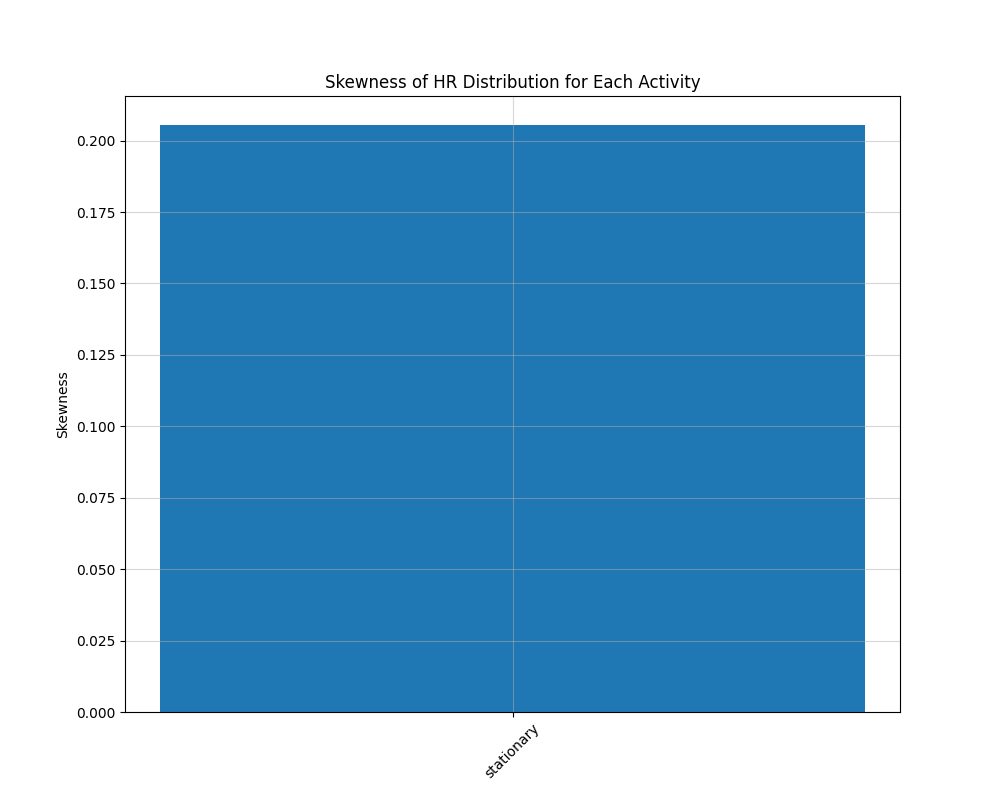

In [27]:
from scipy.stats import skew

activities = df_left_sat['activities'].unique()
skewness_values = []

for act in activities:
    hr_activity = df_left_sat[df_left_sat['activities'] == act]['HR'].dropna()
    if len(hr_activity) > 0:
        sk = skew(hr_activity)
        skewness_values.append(sk)
    else:
        skewness_values.append(0)  # or np.nan if preferred

# Plot a bar chart of skewness values (since histogram for 6 values isn't ideal)
plt.figure(figsize=(10, 8))
plt.bar(activities, skewness_values)
plt.title('Skewness of HR Distribution for Each Activity')
plt.ylabel('Skewness')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.5)
plt.show()

In [28]:
# Save Left dataset (all columns except HR)
left_data = {
    'signal': dataset_Left['signal'],
    'imu_signal': dataset_Left['imu_signal'],
    'subject_ids': dataset_Left['subject_ids'],
    'trial_ids': dataset_Left['trial_ids'],
    'activities': dataset_Left['activities']
}
np.save("itw_Left_data_stationary.npy", left_data, allow_pickle=True)

# Save HR labels dataset (all columns except signal)
hr_labels_data = {
    'HR': dataset_Left['HR'],
    'subject_ids': dataset_Left['subject_ids'],
    'trial_ids': dataset_Left['trial_ids'], 
    'activities': dataset_Left['activities']
}
np.save("itw_HR_labels_data_stationary.npy", hr_labels_data, allow_pickle=True)

print("Datasets saved successfully!")
print(f"  itw_Left_data_stationary.npy - shape: {left_data['signal'].shape} - IMU shape: {left_data['imu_signal'].shape}")
print(f"  itw_HR_labels_data_stationary.npy - HR shape: {hr_labels_data['HR'].shape}")

Datasets saved successfully!
  itw_Left_data_stationary.npy - shape: (1770, 1250) - IMU shape: (1770, 1250)
  itw_HR_labels_data_stationary.npy - HR shape: (1770,)
